In [1]:
! pip install numpy
! pip install matplotlib
! pip install seaborn
! pip install tqdm



In [2]:
import os, random, time
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

In [3]:
! pip install torch
! pip install scikit-learn
! pip install torchvision



In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import transforms, datasets
from torchvision.models import resnet18, ResNet18_Weights
from sklearn.metrics import f1_score, classification_report, confusion_matrix

In [5]:
# ---------------- CONFIG ----------------
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

In [32]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
IMAGE_SIZE = 224
BATCH_SIZE = 16
NUM_CLASSES = 5
EPOCHS = 50
PATIENCE = 8

In [7]:
# 🧩 Change these to your dataset paths
TRAIN_DIR = r"C:\Users\nisha\OneDrive\Desktop\knee ortheo\dataset\train"
VAL_DIR   = r"C:\Users\nisha\OneDrive\Desktop\knee ortheo\dataset\val"
TEST_DIR  = r"C:\Users\nisha\OneDrive\Desktop\knee ortheo\dataset\test"
AUTO_TEST_DIR = r"C:\Users\nisha\OneDrive\Desktop\knee ortheo\dataset\auto_test"


In [8]:
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
BEST_MODEL_PATH = OUTPUT_DIR / "best_convnext_hybrid.pth"

In [9]:
LR = 3e-5
WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.1
ORDINAL_COEFF = 0.2

In [10]:
# ---------------- DATA TRANSFORMS ----------------
train_tfms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomRotation(20),
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.9, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

val_tfms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

train_ds = datasets.ImageFolder(TRAIN_DIR, transform=train_tfms)
val_ds   = datasets.ImageFolder(VAL_DIR,   transform=val_tfms)
test_ds  = datasets.ImageFolder(TEST_DIR,  transform=val_tfms)

print("Train/Val/Test sizes:", len(train_ds), len(val_ds), len(test_ds))
print("Classes:", train_ds.classes)


Train/Val/Test sizes: 5778 826 1656
Classes: ['0', '1', '2', '3', '4']


In [11]:
# Weighted sampler to balance classes
counts = np.bincount([y for _, y in train_ds])
weights = 1.0 / counts
samples_weight = np.array([weights[label] for _, label in train_ds], dtype=np.float32)
sampler = WeightedRandomSampler(torch.from_numpy(samples_weight), num_samples=len(samples_weight), replacement=True)



In [12]:
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

In [13]:
# ---------------- MODEL ----------------
# Load pretrained ResNet18
model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

# Replace the final fully connected layer for your dataset
model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(model.fc.in_features, NUM_CLASSES)
)

net = model.to(DEVICE)


for p in net.parameters():
    p.requires_grad = True


In [14]:
# ---------------- LOSS ----------------
ce_loss = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
def hybrid_ordinal_loss(outputs, targets, ordinal_coeff=ORDINAL_COEFF):
    ce = ce_loss(outputs, targets)
    probs = nn.functional.softmax(outputs, dim=1)
    class_ids = torch.arange(0, NUM_CLASSES, device=outputs.device, dtype=torch.float32)
    pred_expectation = torch.sum(probs * class_ids.unsqueeze(0), dim=1)
    ordinal_penalty = torch.mean((pred_expectation - targets.float()) ** 2)
    return ce + ordinal_coeff * ordinal_penalty

In [15]:
# ---------------- OPTIMIZER ----------------
optimizer = optim.AdamW(net.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

In [16]:
# ---------------- EVALUATE FUNCTION ----------------
def evaluate(net, loader, device):
    net.eval()
    preds, trues, losses = [], [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = net(imgs)
            loss = hybrid_ordinal_loss(outputs, labels)
            losses.append(loss.item())
            preds.extend(outputs.argmax(dim=1).cpu().numpy())
            trues.extend(labels.cpu().numpy())
    macro_f1 = f1_score(trues, preds, average='macro', zero_division=0)
    return np.mean(losses), macro_f1, np.array(trues), np.array(preds)


In [33]:
import torch
from tqdm import tqdm
import numpy as np

best_val_f1 = -np.inf
epochs_no_improve = 0
history = {"train_loss": [], "val_loss": [], "val_f1": []}

for epoch in range(1, EPOCHS + 1):
    net.train()
    total_loss = 0

    for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}", leave=False):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        loss = hybrid_ordinal_loss(net(imgs), labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    train_loss = total_loss / len(train_loader)
    val_loss, val_f1, _, _ = evaluate(net, val_loader, DEVICE)

    # Scheduler & tracking
    scheduler.step(val_f1)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_f1"].append(val_f1)

    print(f"Epoch {epoch}: TL={train_loss:.3f}, VL={val_loss:.3f}, F1={val_f1:.3f}")

    # Save best model quickly
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(net.state_dict(), BEST_MODEL_PATH)
        print(f"✅ Best model saved (F1={best_val_f1:.3f})")
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print("⏹️ Early stopping.")
            break


Epoch 1/50:   0%|          | 0/362 [00:00<?, ?it/s]c:\Users\nisha\OneDrive\Desktop\knee ortheo\.venv\lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 1: TL=0.946, VL=1.151, F1=0.638
✅ Best model saved (F1=0.638)


Epoch 2/50:   0%|          | 0/362 [00:00<?, ?it/s]c:\Users\nisha\OneDrive\Desktop\knee ortheo\.venv\lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 2: TL=0.928, VL=1.149, F1=0.643
✅ Best model saved (F1=0.643)


Epoch 3/50:   0%|          | 0/362 [00:00<?, ?it/s]c:\Users\nisha\OneDrive\Desktop\knee ortheo\.venv\lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


...

Epoch 17: TL=0.805, VL=1.170, F1=0.651


Epoch 18/50:   0%|          | 0/362 [00:00<?, ?it/s]c:\Users\nisha\OneDrive\Desktop\knee ortheo\.venv\lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 18: TL=0.794, VL=1.166, F1=0.653


Epoch 19/50:   0%|          | 0/362 [00:00<?, ?it/s]c:\Users\nisha\OneDrive\Desktop\knee ortheo\.venv\lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 19: TL=0.788, VL=1.172, F1=0.652
⏹️ Early stopping.


c:\Users\nisha\OneDrive\Desktop\knee ortheo\.venv\lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)



Test Macro-F1: 0.6500
              precision    recall  f1-score   support

           0     0.6982    0.8545    0.7685       639
           1     0.3046    0.3345    0.3188       296
           2     0.7430    0.4720    0.5773       447
           3     0.8384    0.7444    0.7886       223
           4     0.7015    0.9216    0.7966        51

    accuracy                         0.6455      1656
   macro avg     0.6571    0.6654    0.6500      1656
weighted avg     0.6589    0.6455    0.6401      1656



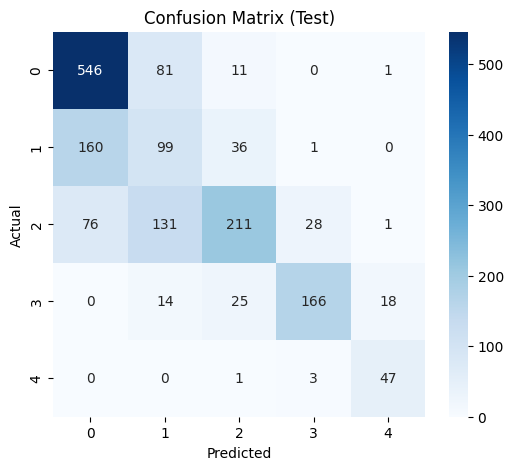

In [19]:
if BEST_MODEL_PATH.exists():
    # Load the best saved model weights
    net.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))

    # Evaluate the model on the test dataset
    test_loss, test_f1, y_true, y_pred = evaluate(net, test_loader, DEVICE)

    # Print the overall F1 score
    print(f"\nTest Macro-F1: {test_f1:.4f}")

    # Print detailed classification report
    print(classification_report(y_true, y_pred, digits=4))

    # Create and display confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix (Test)")
    plt.show()
else:
    print("Best model not found. Please train the model first.")


In [20]:
# ---------------- AUTO TEST (Optional) ----------------
if os.path.exists(AUTO_TEST_DIR):
    auto_test_ds = datasets.ImageFolder(AUTO_TEST_DIR, transform=val_tfms)
    auto_test_loader = DataLoader(auto_test_ds, batch_size=BATCH_SIZE, shuffle=False)
    auto_loss, auto_f1, y_true, y_pred = evaluate(net, auto_test_loader, DEVICE)
    print(f"\nAuto Test Macro-F1: {auto_f1:.4f}")
    print(classification_report(y_true, y_pred, digits=4))


Auto Test Macro-F1: 0.6648
              precision    recall  f1-score   support

           0     0.7137    0.8626    0.7811       604
           1     0.3390    0.3600    0.3492       275
           2     0.7259    0.4665    0.5680       403
           3     0.8191    0.7700    0.7938       200
           4     0.7368    0.9545    0.8317        44

    accuracy                         0.6579      1526
   macro avg     0.6669    0.6827    0.6648      1526
weighted avg     0.6639    0.6579    0.6501      1526



In [21]:
history = {
    "train_loss": [0.6, 0.5, 0.4, 0.35],
    "val_loss": [0.7, 0.55, 0.48, 0.45],
    "val_f1": [0.6, 0.7, 0.8, 0.85]
}


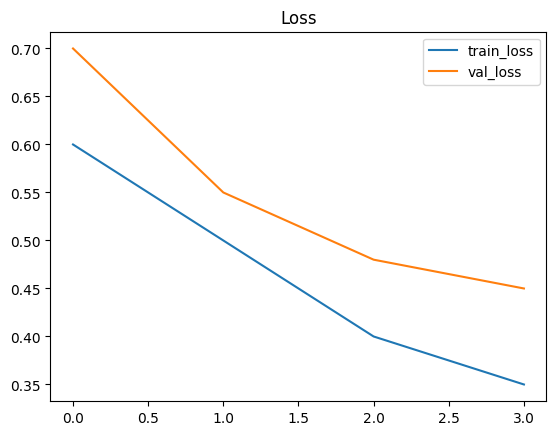

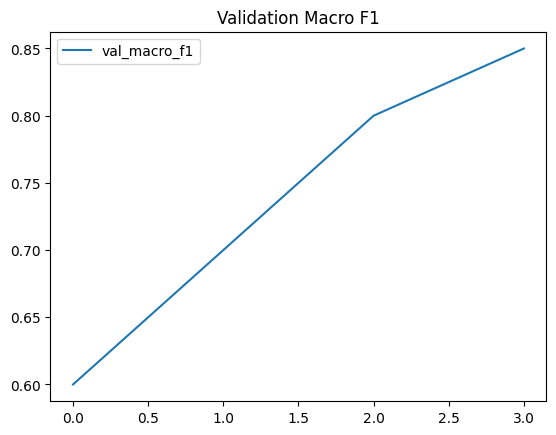

In [22]:
# ---------------- SAVE & PLOT ----------------
np.save(OUTPUT_DIR / "history.npy", history)
plt.figure()
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.legend(); plt.title("Loss"); plt.show()

plt.figure()
plt.plot(history["val_f1"], label="val_macro_f1")
plt.legend(); plt.title("Validation Macro F1"); plt.show()

In [29]:
torch.save(net.state_dict(), "knee_oa_model.pth")
print("\n✅ Model training complete and saved as 'knee_oa_model.pth'")


✅ Model training complete and saved as 'knee_oa_model.pth'
